In [2]:
import cv2
import easyocr
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("OpenCV:", cv2.__version__)
print("All libraries working successfully!")

Creating new Ultralytics Settings v0.0.8 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\WELCOME\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
OpenCV: 5.0.0
All libraries working successfully!


In [3]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("YOLO model loaded successfully!")

YOLO model loaded successfully!


In [4]:
import cv2

video = cv2.VideoCapture("input/traffic.mp4")

if video.isOpened():
    print("Video opened successfully!")
else:
    print("Video not found!")

video.release()


Video opened successfully!


In [10]:
model = YOLO("yolo11n.pt")

In [11]:
from ultralytics import YOLO

plate_model = YOLO(
    "https://huggingface.co/Koushim/yolov8-license-plate-detection/resolve/main/best.pt"
)

print("License plate model loaded!")

License plate model loaded!


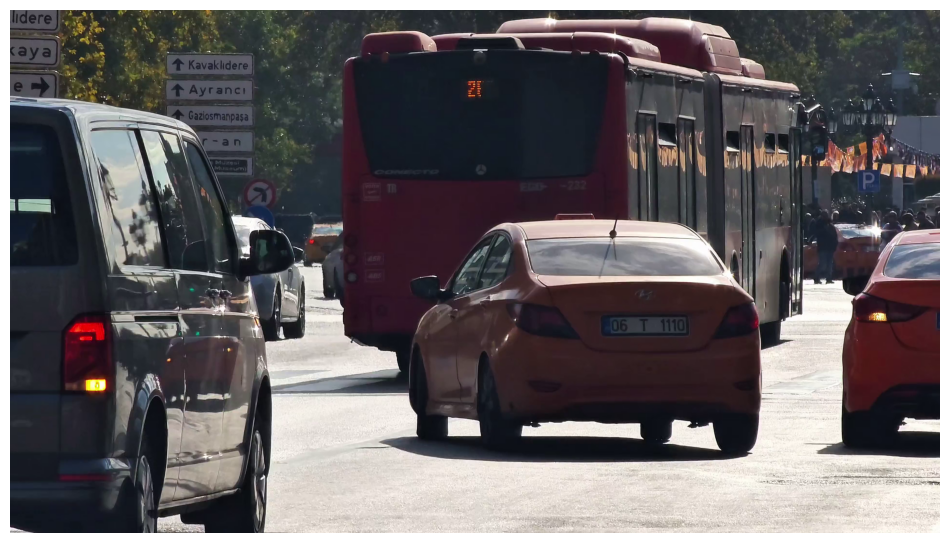

In [18]:
import cv2
import matplotlib.pyplot as plt

video = cv2.VideoCapture("input/traffic.mp4")

ret, frame = video.read()
video.release()

if ret:
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 7))
    plt.imshow(frame)
    plt.axis("off")
    plt.show()
else:
    print("Could not read the video.")


0: 384x640 1 license_plate, 509.7ms
Speed: 29.9ms preprocess, 509.7ms inference, 3.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 license_plates, 667.9ms
Speed: 60.6ms preprocess, 667.9ms inference, 3.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 license_plates, 488.7ms
Speed: 14.2ms preprocess, 488.7ms inference, 2.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 license_plates, 453.9ms
Speed: 56.9ms preprocess, 453.9ms inference, 3.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 license_plates, 506.9ms
Speed: 14.5ms preprocess, 506.9ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 license_plates, 405.7ms
Speed: 46.3ms preprocess, 405.7ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 license_plates, 504.2ms
Speed: 13.5ms preprocess, 504.2ms inference, 3.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 license_plates, 374.4ms
Spee

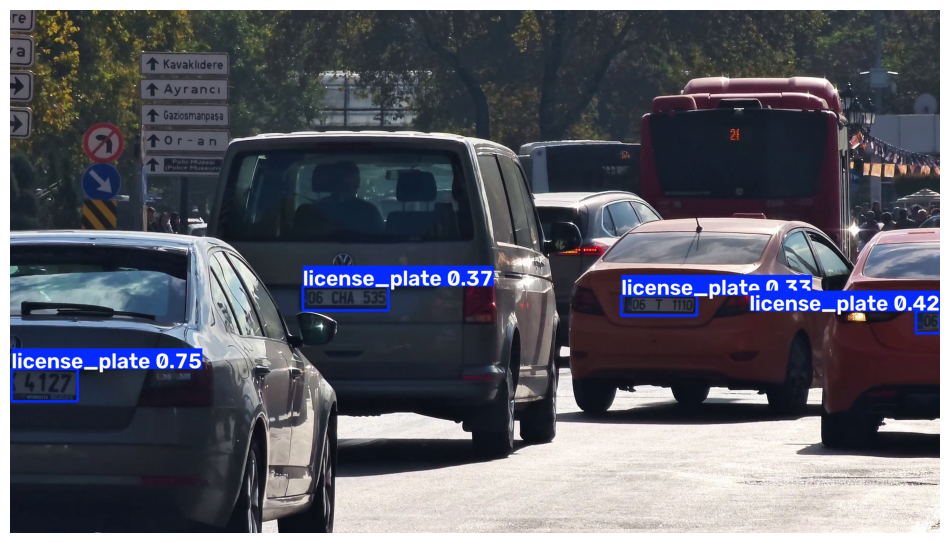

In [19]:
import cv2
import matplotlib.pyplot as plt

video = cv2.VideoCapture("input/traffic.mp4")

best_frame = None
best_count = 0

for i in range(0, 300, 20):
    video.set(cv2.CAP_PROP_POS_FRAMES, i)
    ret, frame = video.read()

    if not ret:
        break

    results = plate_model(frame, conf=0.25)
    count = len(results[0].boxes)

    if count > best_count:
        best_count = count
        best_frame = results[0].plot()

video.release()

print("Maximum plates detected:", best_count)

if best_frame is not None:
    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(best_frame, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()
else:
    print("No plates detected.")


0: 384x640 1 license_plate, 773.6ms
Speed: 28.0ms preprocess, 773.6ms inference, 3.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 license_plates, 1013.0ms
Speed: 74.9ms preprocess, 1013.0ms inference, 4.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 license_plates, 592.8ms
Speed: 30.5ms preprocess, 592.8ms inference, 2.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 license_plates, 554.7ms
Speed: 74.7ms preprocess, 554.7ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 license_plates, 630.7ms
Speed: 24.4ms preprocess, 630.7ms inference, 4.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 license_plates, 772.5ms
Speed: 90.0ms preprocess, 772.5ms inference, 5.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 license_plates, 595.1ms
Speed: 49.4ms preprocess, 595.1ms inference, 4.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 license_plates, 489.5ms
Sp

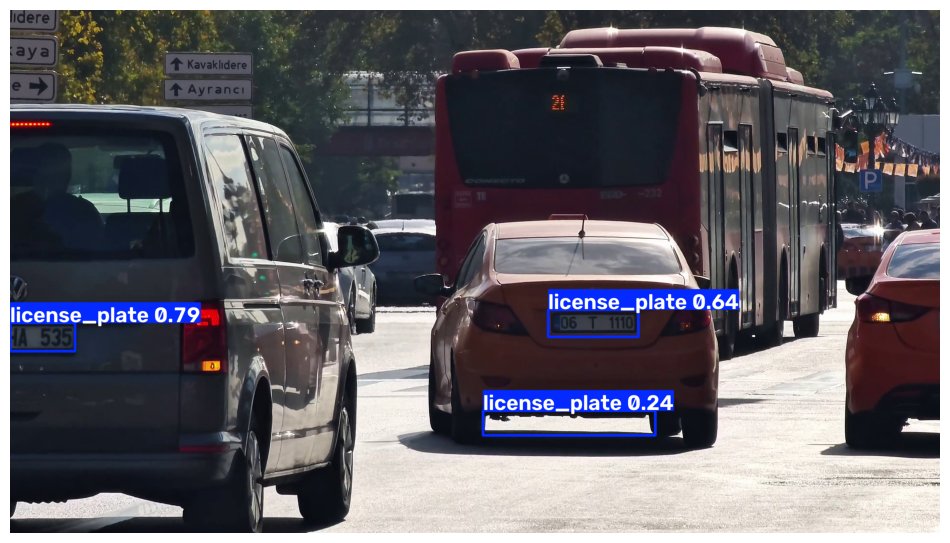

In [21]:
import cv2
import matplotlib.pyplot as plt

video = cv2.VideoCapture("input/traffic.mp4")

best_frame = None
best_count = 0

for i in range(0, 300, 30):
    video.set(cv2.CAP_PROP_POS_FRAMES, i)
    ret, frame = video.read()

    if not ret:
        break

    results = plate_model(frame, conf=0.20)
    count = len(results[0].boxes)

    if count > best_count:
        best_count = count
        best_frame = results[0].plot()

video.release()

print("Maximum plates detected:", best_count)

if best_frame is not None:
    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(best_frame, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

In [2]:
from ultralytics import YOLO

plate_model = YOLO(
    "https://huggingface.co/Koushim/yolov8-license-plate-detection/resolve/main/best.pt"
)

print("License plate model loaded!")

Found https://huggingface.co/Koushim/yolov8-license-plate-detection/resolve/main/best.pt locally at weights\best.pt
License plate model loaded!


In [3]:
import cv2

video = cv2.VideoCapture("input/traffic.mp4")

ret, frame = video.read()
video.release()

if ret:
    results = plate_model(frame, conf=0.20, verbose=False)
    print("YOLO test successful!")
    print("Plates detected:", len(results[0].boxes))
else:
    print("Video could not be opened.")

YOLO test successful!
Plates detected: 1


Using CPU. Note: This module is much faster with a GPU.
C:\Users\WELCOME\anaconda3\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(
C:\Users\WELCOME\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Detected Plate: 06TT


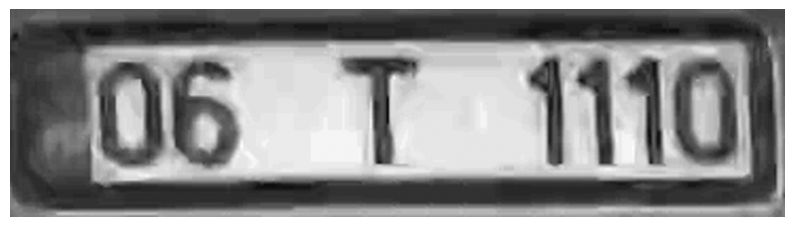

In [3]:
import cv2
import easyocr
import matplotlib.pyplot as plt
import re

reader = easyocr.Reader(['en'], gpu=False)

video = cv2.VideoCapture("input/traffic.mp4")

for i in range(0, 300, 20):

    video.set(cv2.CAP_PROP_POS_FRAMES, i)
    ret, frame = video.read()

    if not ret:
        break

    results = plate_model(frame, conf=0.20, verbose=False)

    if len(results[0].boxes) > 0:

        box = results[0].boxes[0].xyxy[0].cpu().numpy().astype(int)

        x1, y1, x2, y2 = box
        plate = frame[y1:y2, x1:x2]

        plate = cv2.resize(
            plate,
            None,
            fx=5,
            fy=5,
            interpolation=cv2.INTER_CUBIC
        )

        gray = cv2.cvtColor(
            plate,
            cv2.COLOR_BGR2GRAY
        )

        text = reader.readtext(
            gray,
            detail=0,
            allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
        )

        text = re.sub(
            r'[^A-Z0-9]',
            '',
            ''.join(text).upper()
        )

        print("Detected Plate:", text)

        plt.figure(figsize=(10, 3))
        plt.imshow(gray, cmap="gray")
        plt.axis("off")
        plt.show()

        break

video.release()

In [ ]:
import cv2
import easyocr
import re
import csv
import os
import pandas as pd
from collections import defaultdict
from IPython.display import Video, display

# ---------------- SETTINGS ----------------
INPUT = "input/traffic.mp4"
OUTPUT = "outputs/annotated_traffic.mp4"
CSV_FILE = "outputs/traffic_log.csv"

FRAME_SKIP = 10
VERIFY_COUNT = 3
CONFIDENCE = 0.25

os.makedirs("outputs", exist_ok=True)

# ---------------- OCR ----------------
reader = easyocr.Reader(['en'], gpu=False)

# ---------------- VIDEO ----------------
video = cv2.VideoCapture(INPUT)

fps = video.get(cv2.CAP_PROP_FPS)
width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
total = int(video.get(cv2.CAP_PROP_FRAME_COUNT))

out = cv2.VideoWriter(
    OUTPUT,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

# ---------------- PLATE DATA ----------------
history = defaultdict(int)
seen = set()

# ---------------- CSV ----------------
file = open(CSV_FILE, "w", newline="")
csv_writer = csv.writer(file)
csv_writer.writerow(["Video Time", "Number Plate"])

frame_no = 0
last_detections = []

# ---------------- PROCESS ----------------
while True:

    ret, frame = video.read()

    if not ret:
        break

    frame_no += 1

    # Use previous detection for skipped frames
    if frame_no % FRAME_SKIP != 0:

        for x1, y1, x2, y2, text in last_detections:

            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )

            if text:
                cv2.putText(
                    frame,
                    text,
                    (x1, max(30, y1 - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (0, 255, 0),
                    2
                )

        out.write(frame)
        continue

    # ---------------- TIME ----------------
    video_time = frame_no / fps
    time_text = f"{int(video_time//60):02d}:{int(video_time%60):02d}"

    # ---------------- YOLO ----------------
    results = plate_model(
        frame,
        conf=CONFIDENCE,
        verbose=False
    )

    last_detections = []

    for box in results[0].boxes:

        x1, y1, x2, y2 = (
            box.xyxy[0]
            .cpu()
            .numpy()
            .astype(int)
        )

        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(width, x2)
        y2 = min(height, y2)

        plate = frame[y1:y2, x1:x2]

        if plate.size == 0:
            continue

        # ---------------- OCR ----------------
        plate = cv2.resize(
            plate,
            None,
            fx=3,
            fy=3,
            interpolation=cv2.INTER_CUBIC
        )

        gray = cv2.cvtColor(
            plate,
            cv2.COLOR_BGR2GRAY
        )

        result = reader.readtext(
            gray,
            detail=0,
            allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
        )

        text = "".join(result)

        text = re.sub(
            r"[^A-Z0-9]",
            "",
            text.upper()
        )

        # ---------------- VERIFICATION ----------------
        if len(text) >= 4:

            history[text] += 1

            if history[text] >= VERIFY_COUNT:

                if text not in seen:

                    seen.add(text)

                    csv_writer.writerow([
                        time_text,
                        text
                    ])

                    file.flush()

                    print(
                        "New Vehicle:",
                        text,
                        "| Time:",
                        time_text
                    )

        # Save detection for skipped frames
        last_detections.append(
            (x1, y1, x2, y2, text)
        )

        # ---------------- BOX ----------------
        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        if text:

            cv2.putText(
                frame,
                text,
                (x1, max(30, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )

    # ---------------- INFO ----------------
    cv2.rectangle(
        frame,
        (10, 10),
        (360, 85),
        (0, 0, 0),
        -1
    )

    cv2.putText(
        frame,
        f"Time: {time_text}",
        (20, 38),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2
    )

    cv2.putText(
        frame,
        f"Unique Vehicles: {len(seen)}",
        (20, 68),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2
    )

    # ---------------- WRITE ----------------
    out.write(frame)

    # ---------------- PROGRESS ----------------
    if frame_no % (FRAME_SKIP * 10) == 0:

        progress = frame_no / total * 100

        print(
            f"Processing: {progress:.1f}%"
        )

# ---------------- CLOSE ----------------
video.release()
out.release()
file.close()

print("\n==============================")
print("PROCESSING COMPLETED")
print("==============================")
print("Unique vehicles:", len(seen))
print("Video:", OUTPUT)
print("CSV:", CSV_FILE)

# ---------------- DISPLAY VIDEO ----------------
print("\nANNOTATED VIDEO")
display(
    Video(
        OUTPUT,
        embed=True,
        width=800
    )
)

# ---------------- DISPLAY CSV ----------------
print("\nTRAFFIC LOG")

df = pd.read_csv(CSV_FILE)

display(df)

print("\nTotal unique vehicles:", len(df))

Using CPU. Note: This module is much faster with a GPU.
C:\Users\WELCOME\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Processing: 8.3%
New Vehicle: 106TI | Time: 00:03
Processing: 16.6%
New Vehicle: 106T | Time: 00:03
Processing: 25.0%
Processing: 33.3%
New Vehicle: 106I | Time: 00:07
Processing: 41.6%
